In [ ]:


^cd data && unzip -q -o "EGOPER2503.zip" 

## Mapping and stats

In [15]:
import json
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Configuration
BASE = Path("EgoPER_action_segmentation")  # Base directory containing recipe subdirectories
RECIPES = ["pinwheels", "quesadilla", "oatmeal", "coffee", "tea"]

def load_recipe_stats(base, recipes):
    """Load per-recipe statistics including video counts and action mappings."""
    all_stats = []
    for rec in recipes:
        rdir = base / rec
        feat_dir = rdir / "features"
        n_vid = len(list(feat_dir.glob("*.npy"))) if feat_dir.exists() else 0
        
        mapping = load_mapping(rdir)
        all_stats.append({"recipe": rec, "mapping": mapping, "n_video": n_vid})
    return all_stats

def load_mapping(rdir):
    """Load action mapping from mapping.txt or infer from groundTruth labels."""
    map_path = rdir / "mapping.txt"
    if map_path.is_file():
        mapping = {}
        for ln in map_path.read_text().splitlines():
            ln = ln.strip()
            if not ln or "|" not in ln: continue
            idx, name = ln.split("|", 1)
            try:
                mapping[name.strip()] = int(idx)
            except ValueError:
                pass
        return mapping
    
    # Fallback: extract unique actions from label files
    lbl_dir = rdir / "groundTruth"
    if not lbl_dir.is_dir():
        return {}
    
    acts = set()
    for t in lbl_dir.glob("*.txt"):
        acts.update(l.strip() for l in t.read_text().splitlines() if l.strip())
    return {a: i for i, a in enumerate(sorted(acts))}

def create_semantic_mapping(all_stats):
    """Create unified semantic mapping across all recipes (BG=0 as background)."""
    all_names = set()
    for s in all_stats:
        all_names.update(s["mapping"].keys())
    
    sem_map = {"BG": 0}
    for name in sorted(n for n in all_names if n not in {"BG", "background"}):
        sem_map[name] = len(sem_map)
    
    return sem_map

def save_mapping(sem_map, base):
    """Save unified semantic mapping to global mapping file."""
    map_path = base / "mapping_global.txt"
    map_path.parent.mkdir(parents=True, exist_ok=True)
    map_path.write_text("\n".join(f"{i}|{n}" for n, i in sorted(sem_map.items(), key=lambda kv: kv[1])) + "\n")
    return map_path

def analyze_global_distribution(all_stats, sem_map, base):
    """Compute global class distribution across all videos and create statistics."""
    cnt = Counter()
    inv_sem = {v: k for k, v in sem_map.items()}
    
    total_videos = sum(s['n_video'] for s in all_stats)
    total_frames = 0
    
    for s in all_stats:
        feat_dir = base / s["recipe"] / "features"
        lbl_dir = base / s["recipe"] / "groundTruth"
        if not feat_dir.is_dir() or not lbl_dir.is_dir():
            continue
        
        for fp in sorted(feat_dir.glob("*.npy")):
            feat = np.load(fp)
            T = feat.shape[1]
            lbl = lbl_dir / f"{fp.stem}.txt"
            
            if not lbl.is_file():
                labs = [0] * T  # No labels = all background
            else:
                raw = [l.strip() for l in lbl.read_text().splitlines() if l.strip()]
                labs = []
                for name in raw:
                    if name in ("BG", "background"):
                        labs.append(0)
                    elif name in sem_map:
                        labs.append(sem_map[name])
                    else:
                        labs.append(0)  # Unknown = background
                labs = labs[:T]
                if len(labs) < T:
                    labs += [labs[-1]] * (T - len(labs))  # Pad with last label
            
            uniq, counts = np.unique(labs, return_counts=True)
            for cid, c in zip(uniq, counts):
                cnt[cid] += int(c)
            total_frames += T
    
    print_global_stats(total_videos, total_frames, cnt, inv_sem)
    if total_frames > 0:
        create_pie_chart(cnt, inv_sem, total_videos, total_frames, base)
    
    return cnt

def print_global_stats(total_videos, total_frames, cnt, inv_sem):
    """Print dataset overview and top 15 most frequent classes."""
    print(f"\nDataset Overview:")
    print(f"  Total videos:   {total_videos}")
    print(f"  Total frames:   {total_frames:,}")
    print(f"  Unique classes: {len(cnt)} (BG=0)")
    
    if total_frames:
        print("\nTop 15 Most Frequent Classes:")
        for i, (cid, c) in enumerate(cnt.most_common(15), 1):
            name = inv_sem[cid]
            pct = c / sum(cnt.values()) * 100
            print(f"{i:2d}. {name:>40} | {c:>7,} ({pct:5.1f}%)")

def create_pie_chart(cnt, inv_sem, total_videos, total_frames, base):
    """Generate pie chart showing top 20 classes distribution."""
    top20 = cnt.most_common(20)
    other = sum(cnt.values()) - sum(v for _, v in top20)
    
    labels = [
        (inv_sem[cid][:25] + "..." if len(inv_sem[cid]) > 25 else inv_sem[cid])
        for cid, _ in top20
    ] + ["Other"]
    sizes = [v for _, v in top20] + [other]
    
    plt.figure(figsize=(12, 8))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 9})
    plt.title(
        f"EgoPER — Semantic Class Distribution (BG=0)\n"
        f"{total_videos} videos | {total_frames:,} frames | {len(cnt)} classes",
        fontsize=14, pad=20)
    plt.tight_layout()
    
    out_png = base / "egoper_semantic_pie.png"
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.close()
    
    # Save metadata
    meta = {
        "caption": f"EgoPER semantic class distribution ({len(cnt)} unique classes, BG=0)",
        "description": "Background/BG always class 0. Same-named actions unified across recipes."
    }
    (out_png.with_suffix(out_png.suffix + ".meta.json")).write_text(json.dumps(meta, indent=2))
    
    print(f"\nSaved: {out_png}")

def find_missing_actions(map_path, cnt):
    """Identify actions defined in mapping but never observed in data."""
    id2name = {}
    for ln in map_path.read_text().splitlines():
        if not ln.strip(): continue
        idx, name = ln.split("|", 1)
        id2name[int(idx)] = name
    
    missing = [name for idx, name in id2name.items() if cnt.get(idx, 0) == 0]
    print("\nActions Never Observed (count = 0):")
    if missing:
        for m in missing:
            print(f" - {m}")
    else:
        print("  No missing actions – all classes have at least one frame.")

# Main execution
print("="*80)
print("Global Semantic Mapping (BG = class 0)")
print("="*80)

all_stats = load_recipe_stats(BASE, RECIPES)
sem_map = create_semantic_mapping(all_stats)
map_path = save_mapping(sem_map, BASE)

print(f"Unique semantic classes: {len(sem_map)} (BG=0)")
print("Semantic analysis complete! (BG=0 guaranteed)")

print("\n" + "="*80)
print("Global Analysis with Unified Semantic Classes (BG=0)")
print("="*80)

cnt = analyze_global_distribution(all_stats, sem_map, BASE)
find_missing_actions(map_path, cnt)


Global Semantic Mapping (BG = class 0)
Unique semantic classes: 53 (BG=0)
Semantic analysis complete! (BG=0 guaranteed)

Global Analysis with Unified Semantic Classes (BG=0)

Dataset Overview:
  Total videos:   216
  Total frames:   442,368
  Unique classes: 52 (BG=0)

Top 15 Most Frequent Classes:
 1.                                       BG | 131,157 ( 29.6%)
 2.                  Microwave for X seconds |  42,395 (  9.6%)
 3.                         Insert toothpick |  17,826 (  4.0%)
 4.                         Stir using spoon |  12,549 (  2.8%)
 5.          Measure 12 ounces of cold water |  12,110 (  2.7%)
 6.                 Transfer water to kettle |  10,139 (  2.3%)
 7.                              Clean knife |  10,041 (  2.3%)
 8.           Weigh 25 grams of coffee beans |   9,410 (  2.1%)
 9.   Steep tea bag in mug for a few seconds |   9,340 (  2.1%)
10.              Spread butter onto tortilla |   9,287 (  2.1%)
11.                  Check water temperature |   8,294 (  1.

Stats with GroundTruth Global (Unified Text Labels)
Loaded global mapping: 53 classes
Folder Structure:
  coffee/ → ['features', 'groundTruth', 'splits']
  oatmeal/ → ['features', 'groundTruth', 'splits']
  pinwheels/ → ['features', 'groundTruth', 'splits']
  quesadilla/ → ['features', 'groundTruth', 'splits']
  tea/ → ['features', 'groundTruth', 'splits']
━━━ COFFEE ━━━
  Videos: 33 | Frames: 67,584
  Duration: 68.3s ±0.0s
  Unique classes: 15
                                     BG: 13,538 (20.0%)
         Weigh 25 grams of coffee beans:  9,410 (13.9%)
            Grind coffee for 20 seconds:  7,591 (11.2%)
        Measure 12 ounces of cold water:  5,809 ( 8.6%)
        Transfer grounds to filter cone:  5,199 ( 7.7%)
               Transfer water to kettle:  4,437 ( 6.6%)
    Fold paper filter in half to create:  3,881 ( 5.7%)
     Put coffee beans in coffee grinder:  3,875 ( 5.7%)
    Place paper filter in dripper and s:  3,707 ( 5.5%)
    Fold it in half again to create qua:  2,438

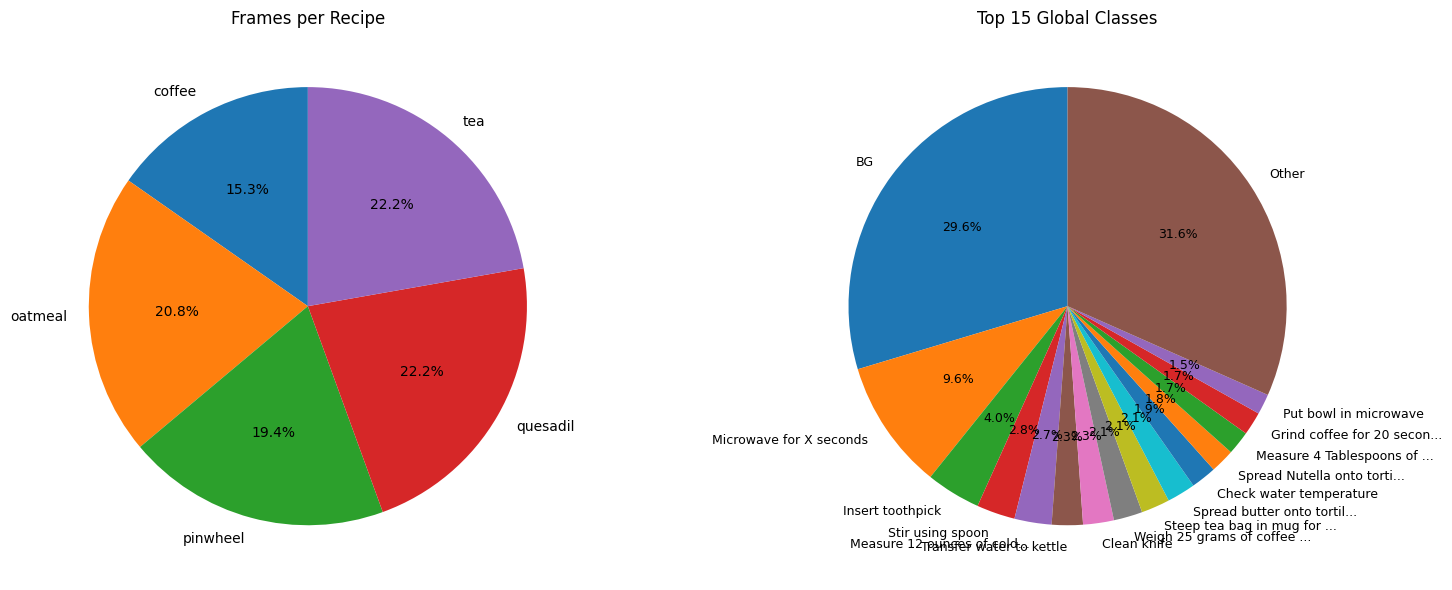


Saved: EgoPER_action_segmentation/egoper_unified_stats.png
Unified stats complete!


In [16]:
import os
import numpy as np
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

def load_global_mapping(base):
    """Load global class mapping from mapping_global.txt (ID|name format)."""
    mapping_path = base / "mapping_global.txt"
    id_to_name = {}
    name_to_id = {}
    
    if mapping_path.exists():
        for line in mapping_path.read_text().splitlines():
            line = line.strip()
            if not line:
                continue
            parts = line.split("|", 1)
            if len(parts) == 2:
                class_id = int(parts[0].strip())
                class_name = parts[1].strip()
                id_to_name[class_id] = class_name
                name_to_id[class_name] = class_id
    
    print(f"Loaded global mapping: {len(id_to_name)} classes")
    return id_to_name, name_to_id

def check_folder_structure(base, recipes):
    """Print unified folder structure for each recipe."""
    print("Folder Structure:")
    for recipe in recipes:
        subdirs = [d.name for d in sorted(recipe.iterdir()) if d.is_dir()]
        print(f"  {recipe.name}/ → {subdirs}")

def compute_recipe_stats(recipe, id_to_name, name_to_id):
    """Compute statistics for single recipe using global mapping."""
    feat_dir = recipe / "features"
    label_dir = recipe / "groundTruth"
    
    if not feat_dir.exists() or not label_dir.exists():
        return None
    
    feat_files = sorted(feat_dir.glob("*.npy"))
    class_counter = Counter()
    durations = []
    
    for fp in feat_files:
        feat = np.load(fp)
        D, T = feat.shape
        durations.append(T / 30.0)  # Assume 30 FPS
        
        lp = label_dir / f"{fp.stem}.txt"
        if not lp.exists():
            continue
        
        raw = [line.strip() for line in lp.read_text().splitlines() if line.strip()]
        if len(raw) == 0:
            continue
        
        # Convert text labels to numeric IDs using global mapping
        bg_id = name_to_id.get("BG", 0)
        parsed_ids = [name_to_id.get(label, bg_id) for label in raw]
        labels = np.array(parsed_ids, dtype=int)
        
        # Pad or trim labels to match feature length T
        if len(labels) < T:
            labels = np.concatenate([labels, np.full(T - len(labels), labels[-1], dtype=int)])
        else:
            labels = labels[:T]
        
        # Count classes in this video
        uniq, counts = np.unique(labels, return_counts=True)
        for cls, cnt in zip(uniq, counts):
            class_counter[int(cls)] += int(cnt)
    
    total_frames = sum(class_counter.values())
    if total_frames == 0:
        return None
    
    return {
        "recipe": recipe.name,
        "n_video": len(feat_files),
        "total_frames": total_frames,
        "mean_dur": float(np.mean(durations)),
        "std_dur": float(np.std(durations)),
        "n_classes": len(class_counter),
        "class_counter": class_counter
    }

def print_recipe_stats(stats):
    """Print detailed statistics for a single recipe."""
    print(f"━━━ {stats['recipe'].upper()} ━━━")
    print(f"  Videos: {stats['n_video']} | Frames: {stats['total_frames']:,}")
    print(f"  Duration: {stats['mean_dur']:.1f}s ±{stats['std_dur']:.1f}s")
    print(f"  Unique classes: {stats['n_classes']}")
    
    total_frames = stats['total_frames']
    top10 = stats['class_counter'].most_common(10)
    for cls, cnt in top10:
        pct = cnt / total_frames * 100
        cls_name = id_to_name.get(cls, f"cls{cls}")
        print(f"    {cls_name[:35]:>35}: {cnt:>6,} ({pct:4.1f}%)")

def compute_global_stats(all_stats_unified, id_to_name):
    """Compute and print global dataset statistics."""
    print("━━━ GLOBAL DATASET STATS ━━━")
    global_counter = Counter()
    for s in all_stats_unified:
        global_counter += s["class_counter"]
    
    tot_frames = sum(global_counter.values())
    total_videos = sum(s["n_video"] for s in all_stats_unified)
    
    if tot_frames > 0:
        print(f"  Total videos: {total_videos}")
        print(f"  Total frames: {tot_frames:,}")
        print(f"  Unique classes: {len(global_counter)}")
        print(f"  Recipes: {len(all_stats_unified)}")
        
        print("\nTop 20 Global Classes:")
        for i, (cls, cnt) in enumerate(global_counter.most_common(20), 1):
            pct = cnt / tot_frames * 100
            cls_name = id_to_name.get(cls, f"cls{cls}")
            print(f"  {i:2d}. {cls_name[:35]:>35}: {cnt:>7,} frames ({pct:5.1f}%)")
        
        return global_counter, tot_frames, total_videos
    return None, 0, 0

def create_visualizations(all_stats_unified, global_counter, id_to_name, tot_frames, total_videos, base):
    """Create dual pie charts: frames per recipe and top classes."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: Frames per recipe
    recipe_totals = [s["total_frames"] for s in all_stats_unified]
    recipe_labels = [s["recipe"][:8] for s in all_stats_unified]
    ax1.pie(recipe_totals, labels=recipe_labels, autopct='%1.1f%%', startangle=90)
    ax1.set_title("Frames per Recipe")
    
    # Right: Top 15 global classes
    top15 = global_counter.most_common(15)
    other = tot_frames - sum(c[1] for c in top15)
    
    pie_labels = [
        (id_to_name.get(c[0], f"cls{c[0]}")[:25] + "...")
        if len(id_to_name.get(c[0], f"cls{c[0]}")) > 25
        else id_to_name.get(c[0], f"cls{c[0]}")
        for c in top15
    ] + ["Other"]
    
    pie_sizes = [c[1] for c in top15] + [other]
    
    ax2.pie(pie_sizes, labels=pie_labels, autopct='%1.1f%%', 
            startangle=90, textprops={'fontsize': 9})
    ax2.set_title("Top 15 Global Classes")
    
    plt.tight_layout()
    output_png = base / "egoper_unified_stats.png"
    plt.savefig(output_png, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved: {output_png}")

# Main execution
base = Path("EgoPER_action_segmentation")  # Base directory containing recipe subdirectories
recipes = sorted([d for d in base.iterdir() if d.is_dir()])

print("=" * 80)
print("Stats with GroundTruth Global (Unified Text Labels)")
print("=" * 80)

id_to_name, name_to_id = load_global_mapping(base)
check_folder_structure(base, recipes)

# Compute per-recipe statistics
all_stats_unified = []
for recipe in recipes:
    stats = compute_recipe_stats(recipe, id_to_name, name_to_id)
    if stats:
        print_recipe_stats(stats)
        all_stats_unified.append(stats)
    else:
        print(f"Skip {recipe.name}: no valid data")
    print()

# Global analysis and visualization
global_counter, tot_frames, total_videos = compute_global_stats(all_stats_unified, id_to_name)

if tot_frames > 0:
    create_visualizations(all_stats_unified, global_counter, id_to_name, tot_frames, total_videos, base)
else:
    print("\nNo valid frames found.")

print("Unified stats complete!")

## Graph

In [30]:
!ls
!mv /EgoPER_action_segmentation /ProTAS_Dovid308/data
!ls



!mv EgoPER_action_segmentation ProTAS_Dovid308/data

EGOPER2503.zip		    ProTAS_Dovid308
EgoPER_action_segmentation  egoper_preprocessing.ipynb
mv: cannot stat '/EgoPER_action_segmentation': No such file or directory
EGOPER2503.zip		    ProTAS_Dovid308
EgoPER_action_segmentation  egoper_preprocessing.ipynb


In [31]:
%cd ProTAS_Dovid308/
!python3 utils/write_graph.py

/home/dovid308/ProtasExp/ProTAS_Dovid308


/home/dovid308/miniforge3/envs/protas/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


Graph coffee: 100%|████████████████████████████| 33/33 [00:00<00:00, 444.06it/s]
Finished writing graph for coffee in data/EgoPER_action_segmentation/coffee/graph
Graph tea: 100%|██████████████████████████████| 48/48 [00:00<00:00, 1817.39it/s]
Finished writing graph for tea in data/EgoPER_action_segmentation/tea/graph
Graph pinwheels: 100%|█████████████████████████| 42/42 [00:00<00:00, 473.95it/s]
Finished writing graph for pinwheels in data/EgoPER_action_segmentation/pinwheels/graph
Graph oatmeal: 100%|██████████████████████████| 45/45 [00:00<00:00, 1092.66it/s]
Finished writing graph for oatmeal in data/EgoPER_action_segmentation/oatmeal/graph
Graph quesadilla: 100%|███████████████████████| 48/48 [00:00<00:00, 2714.17it/s]
Finished writing graph for quesadilla in data/EgoPER_action_segmentation/quesadilla/graph

✅ Global graph successfully created at: data/EgoPER_action_segmentation/graph/graph.pkl


In [37]:
import pickle
import numpy as np
import os
import textwrap

path = "/data/EgoPER_action_segmentation/graph/graph.pkl"

if not os.path.exists(path):
    print(f"❌ Error: File not found at '{path}'.")
    print("   The 'write_graph.py' script might have failed to create it or the path is wrong.")
elif os.path.getsize(path) == 0:
    print(f"❌ Error: File '{path}' is empty.")
    print("   The 'write_graph.py' script likely failed to populate it correctly.")
else:
    try:
        with open(path, "rb") as f:
            obj = pickle.load(f)

        print("=" * 60)
        print("📊 PICKLE FILE ANALYSIS")
        print("=" * 60)
        print(f"FILE: {path}")
        print(f"TYPE: {type(obj).__name__}")

        if isinstance(obj, dict):
            print("\n🔑 TOP-LEVEL KEYS:")
            for k in obj.keys():
                print(f"  - {k}")

            print("\n📝 DICT SUMMARY:")
            for k, v in obj.items():
                shape = getattr(v, "shape", None)
                dtype = getattr(v, "dtype", None)

                # Formattazione chiara per ogni chiave
                print(f"  🔹 {k}:")
                print(f"     Type  : {type(v).__name__}")
                if shape is not None:
                    print(f"     Shape : {shape}")
                if dtype is not None:
                    print(f"     Dtype : {dtype}")

                # Se è una matrice numpy, stampiamo un piccolo sample 3x3
                if isinstance(v, np.ndarray) and v.size > 0:
                    print("     Sample (3x3):")

                    # Prendiamo un sample (max 3x3) e lo arrotondiamo a 3 decimali per leggibilità
                    r_max = min(v.shape[0], 3)
                    c_max = min(v.shape[1], 3) if len(v.shape) > 1 else 1

                    if len(v.shape) > 1:
                        sample_str = str(np.round(v[:r_max, :c_max], 3))
                    else:
                        sample_str = str(np.round(v[:r_max], 3))

                    print(textwrap.indent(sample_str, "       "))
            print("=" * 60 + "\n")

        elif isinstance(obj, (list, tuple)):
            print("\n📏 LENGTH:", len(obj))
            print("\n📄 FIRST ITEMS:")
            for i, item in enumerate(obj[:5]):
                shape = getattr(item, "shape", None)
                length = len(item) if hasattr(item, "__len__") else "N/A"
                print(f"[{i}] type={type(item).__name__}, len={length}, shape={shape}")

        else:
            print("\n📦 CONTENT:")
            from pprint import pprint
            pprint(obj)

    except pickle.UnpicklingError as e:
        print(f"❌ UnpicklingError: Failed to load '{path}'.")
        print("   This usually means the file is corrupted or not a valid pickle file.")
        print(f"   Details: {e}")
    except Exception as e:
        print(f"❌ An unexpected error occurred: {e}")


❌ Error: File not found at '/data/EgoPER_action_segmentation/graph/graph.pkl'.
   The 'write_graph.py' script might have failed to create it or the path is wrong.


## Progress 
The original utils are modifed todo this



In [38]:
!python3 utils/write_progress_values.py

🎯 GENERATING INDIVIDUAL PROGRESS VALUES (Original Logic)
Progress coffee: 100%|█████████████████████████| 33/33 [00:00<00:00, 336.07it/s]
Finished writing progress values for coffee in data/EgoPER_action_segmentation/coffee/progress
Progress tea: 100%|███████████████████████████| 48/48 [00:00<00:00, 1022.08it/s]
Finished writing progress values for tea in data/EgoPER_action_segmentation/tea/progress
Progress pinwheels: 100%|██████████████████████| 42/42 [00:00<00:00, 554.12it/s]
Finished writing progress values for pinwheels in data/EgoPER_action_segmentation/pinwheels/progress
Progress oatmeal: 100%|████████████████████████| 45/45 [00:00<00:00, 712.55it/s]
Finished writing progress values for oatmeal in data/EgoPER_action_segmentation/oatmeal/progress
Progress quesadilla: 100%|████████████████████| 48/48 [00:00<00:00, 1868.48it/s]
Finished writing progress values for quesadilla in data/EgoPER_action_segmentation/quesadilla/progress

🌍 GENERATING UNIFIED GLOBAL PROGRESS VALUES
Global P

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = "/content/ProTAS_Dovid308/data/EgoPER_action_segmentation/pinwheels/progress_global/pinwheels_u1_a1_normal_016.npy"
data = np.load(path)

print("SHAPE:", data.shape)
print("DTYPE:", data.dtype)
print("MIN/MAX:", data.min(), data.max())
print("MEAN/STD:", data.mean(), data.std())

# Salva CSV per esplorare in Excel/Sheets
np.savetxt('S1_Cheese_C1.csv', data, delimiter=',')
print("Salvato: S1_Cheese_C1.csv")

if data.ndim == 1:
    # Vettore progress (tipico)
    plt.figure(figsize=(12, 4))
    plt.plot(data)
    plt.title("S1_Cheese_C1 Progress")
    plt.xlabel("Frame")
    plt.ylabel("Progress")
    plt.grid(True)
    plt.show()

    print("PRIMI 10:", data[:10])
    print("ULTIMI 10:", data[-10:])

elif data.ndim == 2:
    plt.figure(figsize=(10, 6))
    plt.imshow(data, aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title("S1_Cheese_C1 Matrix")
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = "/content/ProTAS_Dovid308/data/EgoPER_action_segmentation/pinwheels/progress/pinwheels_u1_a1_normal_016.npy"
data = np.load(path)

print("SHAPE:", data.shape)
print("DTYPE:", data.dtype)
print("MIN/MAX:", data.min(), data.max())
print("MEAN/STD:", data.mean(), data.std())

# Salva CSV per esplorare in Excel/Sheets
np.savetxt('S1_Cheese_C1.csv', data, delimiter=',')
print("Salvato: S1_Cheese_C1.csv")

if data.ndim == 1:
    # Vettore progress (tipico)
    plt.figure(figsize=(12, 4))
    plt.plot(data)
    plt.title("S1_Cheese_C1 Progress")
    plt.xlabel("Frame")
    plt.ylabel("Progress")
    plt.grid(True)
    plt.show()

    print("PRIMI 10:", data[:10])
    print("ULTIMI 10:", data[-10:])

elif data.ndim == 2:
    plt.figure(figsize=(10, 6))
    plt.imshow(data, aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title("S1_Cheese_C1 Matrix")
    plt.show()

## Splits




In [40]:
from pathlib import Path

BASE = Path("data/EgoPER_action_segmentation")
RECIPES = ["coffee", "tea", "pinwheels", "oatmeal", "quesadilla"]

GLOBAL_SPLITS_DIR = BASE / "splits"
GLOBAL_SPLITS_DIR.mkdir(parents=True, exist_ok=True)

GT_DIRNAME = "groundTruth"

# Raggruppa gli split con lo stesso nome tra tutte le recipe
split_name_to_paths = {}
for recipe in RECIPES:
    splits_dir = BASE / recipe / "splits"
    if not splits_dir.is_dir():
        continue

    for split_file in sorted(splits_dir.glob("*.bundle")):
        split_name_to_paths.setdefault(split_file.name, []).append(split_file)

# === FASE 1: crea gli split globali ===
for split_name, paths in split_name_to_paths.items():
    global_lines = []

    for split_path in paths:
        recipe = split_path.parent.parent.name

        with split_path.open("r") as f:
            vids = [line.strip() for line in f if line.strip()]

        for v in vids:
            video_name = Path(v).name
            global_lines.append(f"{recipe}/{GT_DIRNAME}/{video_name}")

    out_path = GLOBAL_SPLITS_DIR / split_name
    with out_path.open("w") as f:
        f.write("\n".join(global_lines) + "\n")

    print(f"✅ Global {split_name}: {len(global_lines)} videos")

print("\n=== FASE 1 OK ===")

# === FASE 2: riscrivi gli split locali in-place ===
print("\nModificando split originali...")

for recipe in RECIPES:
    splits_dir = BASE / recipe / "splits"
    if not splits_dir.is_dir():
        continue

    for split_file in sorted(splits_dir.glob("*.bundle")):
        with split_file.open("r") as f:
            vids = [line.strip() for line in f if line.strip()]

        updated = [f"{GT_DIRNAME}/{Path(v).name}" for v in vids]

        with split_file.open("w") as f:
            f.write("\n".join(updated) + "\n")

        print(f"✅ {recipe}/{split_file.name}: {len(updated)} videos")

print("=== TUTTO FATTO! ===")

✅ Global test.split1.bundle: 53 videos
✅ Global train.split1.bundle: 163 videos

=== FASE 1 OK ===

Modificando split originali...
✅ coffee/test.split1.bundle: 8 videos
✅ coffee/train.split1.bundle: 25 videos
✅ tea/test.split1.bundle: 12 videos
✅ tea/train.split1.bundle: 36 videos
✅ pinwheels/test.split1.bundle: 10 videos
✅ pinwheels/train.split1.bundle: 32 videos
✅ oatmeal/test.split1.bundle: 11 videos
✅ oatmeal/train.split1.bundle: 34 videos
✅ quesadilla/test.split1.bundle: 12 videos
✅ quesadilla/train.split1.bundle: 36 videos
=== TUTTO FATTO! ===
